# Challenge 2 — Financial Health Classification

## Model Training

The exploratory analysis identified the main structure of the problem: financially stronger firms concentrate in the upper classes, weaker firms in the lower ones, and the most informative signals are mainly related to profitability, leverage, debt burden, and liquidity.

The modeling phase translates those findings into a predictive pipeline designed to be:

| Principle | Modeling implication |
|---|---|
| **Time-aware** | validation is based on a chronological split |
| **Economically coherent** | features are chosen for signal and interpretability |
| **Ordinally consistent** | errors are evaluated not only by correctness, but also by distance across classes |
| **Robust** | the final choice is checked against leakage and overfitting concerns |

The target preserves its ordered financial meaning:

- **A** → strongest condition  
- **B** → solid condition  
- **C** → weaker condition  
- **D** → highest financial risk  

This means that the task is not just to maximize exact classification, but also to keep prediction errors **close to the true financial state**.

## 1. Setup and data loading


In [25]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)
from sklearn.model_selection import RandomizedSearchCV, GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

from pathlib import Path
output_path = Path("../data/final")
output_path.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

TARGET = "financial_health_class"
CLASS_ORDER = ["A", "B", "C", "D"]

### Data loading and temporal coverage

The processed datasets are loaded first to preserve full consistency with the EDA.

A quick check on `fiscal_year` confirms the expected chronological structure:

| Dataset | Time span | Role |
|---|---:|---|
| Train | **2018–2021** | historical data used for learning and validation |
| Test | **2022–2023** | future unseen period for final prediction |

This matters because the task is naturally **forward-looking**: the model must learn from past company observations and generalize to later years.

In [26]:
try:
    train_df
except NameError:
    train_df = pd.read_csv("../data/processed/train_data.csv")

try:
    test_df
except NameError:
    test_df = pd.read_csv("../data/processed/test_features.csv")

train_years = sorted(train_df["fiscal_year"].astype(int).unique().tolist())
test_years = sorted(test_df["fiscal_year"].astype(int).unique().tolist())

print(f"Train years: {train_years}")
print(f"Test years: {test_years}")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train years: [2018, 2019, 2020, 2021]
Test years: [2022, 2023]
Train shape: (11828, 30)
Test shape: (5811, 27)


## 2. Feature engineering guided by the EDA

The EDA already showed that the strongest signal comes from a compact set of financial ratios, while some missing values also carry useful information.

So the feature engineering is kept **deliberate rather than excessive**:

- preserve the strongest accounting signals,
- add transformations that improve scale stability,
- encode informative missingness explicitly,
- and keep categorical context available without overcomplicating the pipeline.

The goal is to enrich the raw data just enough to improve modeling quality while keeping the final feature space readable and economically meaningful.

In [27]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Missing indicators (EDA showed they are informative)
    for col in ["roe", "leverage", "province"]:
        if col in out.columns:
            out[f"{col}_missing"] = out[col].isnull().astype(int)

    # Engineered operating cost ratio
    if {"production_costs", "production_value"}.issubset(out.columns):
        out["op_cost_ratio"] = out["production_costs"] / out["production_value"].replace(0, np.nan)

    # Log-transformed scale variables (to reduce skewness)
    log_candidates = [
        "total_assets", "total_debt", "current_assets", "total_fixed_assets",
        "shareholders_equity", "production_value", "production_costs",
        "short_term_debt", "long_term_debt"
    ]

    for col in log_candidates:
        if col in out.columns:
            x = out[col].copy()
            x = x.where(x > 0, np.nan)
            out[f"log_{col}"] = np.log1p(x)

    # Cast categoricals
    categorical_candidates = ["region", "province", "legal_form", "ateco_sector"]
    for col in categorical_candidates:
        if col in out.columns:
            out[col] = out[col].astype("object")
            out[col] = out[col].where(out[col].notna(), np.nan)

    return out

df_model = build_features(train_df)
df_test_model = build_features(test_df)
print("Feature engineering applied successfully.")
print("New columns:", df_model.shape[1] - train_df.shape[1])

Feature engineering applied successfully.
New columns: 13


### What is added here

The feature builder adds three types of information:

| Component | What it does | Why it matters |
|---|---|---|
| **Missing-value flags** | creates indicators such as `roe_missing`, `leverage_missing`, `province_missing` | preserves the signal from non-random missingness |
| **Engineered operating ratio** | computes `op_cost_ratio = production_costs / production_value` | captures cost pressure relative to output |
| **Log-transformed size variables** | creates `log_total_assets`, `log_total_debt`, etc. | reduces skewness and makes scale effects more stable |

Categorical fields (`region`, `province`, `legal_form`, `ateco_sector`) are also explicitly cast to object type so they can be handled cleanly in the preprocessing pipeline.

Overall, this is a **compact but high-value** engineering step: the dataset becomes richer without losing interpretability.

### Final feature set

The final feature space is selected with three priorities:

- **predictive signal**
- **stability across years**
- **economic interpretability**

Instead of expanding every possible variable, the selection stays focused on the features that are most likely to generalize.

#### Structure of the final feature set

- **Core financial ratios**  
  `roe`, `roi`, `profit_margin`, `leverage`, `debt_to_assets`, `current_ratio`, `quick_ratio`, `op_cost_ratio`

- **Scale-adjusted balance sheet / income statement variables**  
  log-transformed size proxies such as assets, debt, current assets, equity, production value, and production costs

- **Firm maturity**  
  `years_in_business`

- **Missingness indicators**  
  engineered flags for selected variables

- **Categorical context**  
  `region`, `province`, `legal_form`, `ateco_sector`

This keeps the model grounded in a small number of **high-information financial signals**, with just enough contextual structure to support separation when ratios alone are not sufficient.


In [28]:
candidate_features = [
    # Core financial ratios
    "roe", "roi", "profit_margin", "leverage",
    "debt_to_assets", "current_ratio", "quick_ratio", "op_cost_ratio",

    # Log scale features
    "log_total_assets", "log_total_debt", "log_current_assets",
    "log_shareholders_equity", "log_production_value", "log_production_costs",

    # Firm characteristics
    "years_in_business",

    # Missing indicators
    "roe_missing", "leverage_missing", "province_missing",

    # Categorical context
    "region", "province", "legal_form", "ateco_sector",
]

FEATURES = [c for c in candidate_features if c in df_model.columns]

print(f"Selected features: {len(FEATURES)}")
pd.DataFrame({
    "feature": FEATURES
}).head(30)

Selected features: 22


,feature
0,roe
1,roi
2,profit_margin
3,leverage
4,debt_to_assets
5,current_ratio
6,quick_ratio
7,op_cost_ratio
8,log_total_assets
9,log_total_debt


## 3. Temporal validation design

The validation split is chronological by construction.

| Split | Fiscal years | Purpose |
|---|---:|---|
| **Training** | **2018–2020** | fit the models |
| **Validation** | **2021** | evaluate true out-of-sample performance |

This is the correct design for the challenge.

A random split would mix earlier and later observations, making the task artificially easier and weakening the realism of the validation.  
Using a temporal holdout keeps the evaluation aligned with the actual forecasting setting.

Train shape: (8896, 22)
Validation shape: (2932, 22)


,train,validation
financial_health_class,,
A,0.084645,0.085266
B,0.598696,0.576739
C,0.227743,0.246930
D,0.088916,0.091064


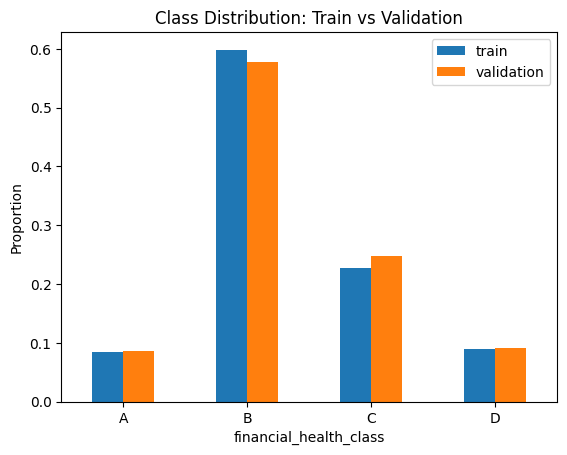

In [29]:
train_mask = df_model["fiscal_year"].isin([2018, 2019, 2020])
val_mask = df_model["fiscal_year"] == 2021

X_train = df_model.loc[train_mask, FEATURES].copy()
y_train = df_model.loc[train_mask, TARGET].copy()

X_val = df_model.loc[val_mask, FEATURES].copy()
y_val = df_model.loc[val_mask, TARGET].copy()

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

train_dist = y_train.value_counts(normalize=True).sort_index()
val_dist = y_val.value_counts(normalize=True).sort_index()
dist_df = pd.DataFrame({
    "train": train_dist,
    "validation": val_dist
})

display(dist_df)

dist_df.plot(kind="bar")
plt.title("Class Distribution: Train vs Validation")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

### Class stability and target encoding

Before training, two things matter:

#### 1) Class distribution remains usable
The class mix stays sufficiently stable between the 2018–2020 training window and the 2021 validation year, so the holdout is not distorted by an extreme class shift.

#### 2) The target keeps its ordinal structure
The labels are encoded in order:

| Class | Encoded value | Meaning |
|---|---:|---|
| **A** | 0 | strongest financial condition |
| **B** | 1 | solid / intermediate |
| **C** | 2 | weaker condition |
| **D** | 3 | highest financial risk |

This encoding is not just technical.  
It also allows the evaluation stage to measure **how far** a wrong prediction is from the true class, which is essential in an ordered rating problem.

In [30]:
label_encoder = LabelEncoder()
label_encoder.fit(CLASS_ORDER)

y_train_enc = label_encoder.transform(y_train)
y_val_enc = label_encoder.transform(y_val)

print("Encoded classes:", label_encoder.classes_)

Encoded classes: ['A' 'B' 'C' 'D']


### Preprocessing pipeline

The feature matrix contains both numerical and categorical variables, so preprocessing is handled by type.

#### Numerical branch
- **median imputation**
- **standard scaling**

#### Categorical branch
- **most-frequent imputation**
- **one-hot encoding** with `handle_unknown="ignore"`

This design is clean and robust:

- missing values are handled explicitly,
- scale-sensitive models receive normalized inputs,
- categorical variables remain usable without manual recoding,
- and all models are compared under the **same preprocessing logic**.

That last point is important: the benchmark should compare **models**, not different data-preparation choices.

In [31]:
numeric_features = X_train.select_dtypes(include=["number", "float64", "int64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

pd.DataFrame({
    "numeric_features": pd.Series(numeric_features),
    "categorical_features": pd.Series(categorical_features)
})

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])


## 4. Baseline model benchmark

The first comparison uses a small but strong set of baseline models covering different modeling families.

| Model | Why it is included |
|---|---|
| **Logistic Regression** | clean linear benchmark with class balancing |
| **Random Forest** | captures nonlinear interactions and threshold effects |
| **HistGradientBoosting** | strong tabular baseline, efficient and robust |
| **XGBoost** *(if available)* | high-capacity boosted trees, often strong on structured data |

This is a good starting mix because it tests whether the class boundaries are mostly:

- **linear and regularized**, or
- **nonlinear and interaction-heavy**.

Given what emerged in the EDA, the expectation is that the best performance should come from the **tree-based ensemble family**.

In [32]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.05,
        max_iter=300,
        random_state=SEED
    )
}

if HAS_XGB:
    models["XGBoost"] = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="multi:softprob",
        num_class=4,
        eval_metric="mlogloss",
        random_state=SEED
    )

In [33]:
def ordinal_mae(y_true_enc, y_pred_enc):
    return np.mean(np.abs(y_true_enc - y_pred_enc))

def evaluate_predictions(y_true, y_pred, label_encoder):
    y_true_enc = label_encoder.transform(y_true)
    y_pred_enc = label_encoder.transform(y_pred)

    return {
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "accuracy": accuracy_score(y_true, y_pred),
        "ordinal_mae": ordinal_mae(y_true_enc, y_pred_enc)
    }

def build_pipeline(model):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

### Evaluation framework

The comparison is intentionally built around **both standard classification quality and ordinal coherence**.

#### Metrics used

| Metric | What it captures | Why it matters here |
|---|---|---|
| **Weighted F1** | main overall performance metric | robust multiclass summary, weighted by class frequency |
| **Macro F1** | balance across classes | checks whether weaker classes are being ignored |
| **Accuracy** | exact matches | simple and intuitive benchmark |
| **Ordinal MAE** | average distance between true and predicted class | penalizes large jumps across the `A → D` scale |

This combination is much more informative than accuracy alone.

In this problem, a model should not only predict well — it should also make **small mistakes rather than severe ones**.

### Baseline comparison

All baseline models are trained under the exact same conditions:

- same **feature set**
- same **temporal split**
- same **preprocessing**
- same **evaluation metrics**

So the ranking that follows is directly interpretable: differences in performance come from the model family itself, not from changes in the data pipeline.

In [34]:
results = []
fitted_pipelines = {}

for model_name, model in models.items():
    pipe = build_pipeline(model)
    pipe.fit(X_train, y_train_enc)

    pred_enc = pipe.predict(X_val)
    pred = label_encoder.inverse_transform(pred_enc)

    metrics = evaluate_predictions(y_val, pred, label_encoder)
    metrics["model"] = model_name

    results.append(metrics)
    fitted_pipelines[model_name] = pipe

results_df = pd.DataFrame(results).sort_values(
    by=["weighted_f1", "macro_f1"], ascending=False
).reset_index(drop=True)

for col in df_model.columns:
    if df_model[col].dtype == "object":
        df_model[col] = df_model[col].replace({pd.NA: np.nan})

for col in df_test_model.columns:
    if df_test_model[col].dtype == "object":
        df_test_model[col] = df_test_model[col].replace({pd.NA: np.nan})

display(results_df.style.format({
    "weighted_f1": "{:.4f}",
    "macro_f1": "{:.4f}",
    "accuracy": "{:.4f}",
    "ordinal_mae": "{:.4f}"
}))

,weighted_f1,macro_f1,accuracy,ordinal_mae,model
0,0.9966,0.9957,0.9966,0.0034,Random Forest
1,0.9952,0.9933,0.9952,0.0048,HistGradientBoosting
2,0.8712,0.8481,0.8677,0.1327,Logistic Regression


### Reading the first ranking

The baseline comparison usually reveals the same pattern suggested by the EDA:

- the **linear benchmark** provides a useful floor,
- but the strongest performance tends to come from **tree-based ensembles**,
- especially when class boundaries depend on interactions between profitability, leverage, liquidity, and firm structure.

That makes the next step straightforward: refine the best-performing ensemble models rather than tuning every model indiscriminately.

## 5. Hyperparameter tuning

The baseline phase identifies the strongest model families.  
Tuning is then used as a **targeted refinement step**, not as a blind search.

Only the most promising tree-based models are tuned, because they are the ones most likely to benefit from controlled changes in:

- model complexity,
- tree depth,
- learning rate,
- ensemble size,
- and regularization through sampling / leaf constraints.

This keeps the process efficient and methodologically clean.

In [35]:
import numpy as np
import pandas as pd

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score, accuracy_score

# --------------------------------------------------
# 1) Main chronological split
# --------------------------------------------------
train_mask = df_model["fiscal_year"].isin([2018, 2019, 2020])
val_mask = df_model["fiscal_year"] == 2021

train_data = df_model.loc[train_mask].copy().reset_index(drop=True)
val_data = df_model.loc[val_mask].copy().reset_index(drop=True)

X_train = train_data[FEATURES].copy()
y_train = train_data[TARGET].copy()

X_val = val_data[FEATURES].copy()
y_val = val_data[TARGET].copy()

# encode target if needed by the models / previous pipeline logic
y_train_enc = label_encoder.transform(y_train)
y_val_enc = label_encoder.transform(y_val)

print("Train years:", sorted(train_data["fiscal_year"].unique()))
print("Validation years:", sorted(val_data["fiscal_year"].unique()))
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

# --------------------------------------------------
# 2) Custom temporal CV inside train only
#    Fold 1: train 2018 -> validate 2019
#    Fold 2: train 2018-2019 -> validate 2020
# --------------------------------------------------
fold1_train_idx = np.where(train_data["fiscal_year"] == 2018)[0]
fold1_val_idx = np.where(train_data["fiscal_year"] == 2019)[0]

fold2_train_idx = np.where(train_data["fiscal_year"].isin([2018, 2019]))[0]
fold2_val_idx = np.where(train_data["fiscal_year"] == 2020)[0]

temporal_cv = [
    (fold1_train_idx, fold1_val_idx),
    (fold2_train_idx, fold2_val_idx),
]

print("Fold 1 -> train:", len(fold1_train_idx), "validation:", len(fold1_val_idx))
print("Fold 2 -> train:", len(fold2_train_idx), "validation:", len(fold2_val_idx))

# --------------------------------------------------
# 3) Parameter distributions
# --------------------------------------------------
param_distributions = {
    "Random Forest": {
        "model__n_estimators": randint(200, 800),
        "model__max_depth": randint(5, 20),
        "model__min_samples_leaf": randint(1, 10),
    },
    "HistGradientBoosting": {
        "model__max_depth": randint(3, 10),
        "model__learning_rate": uniform(0.01, 0.1),
        "model__max_iter": randint(200, 600),
    }
}

if HAS_XGB:
    param_distributions["XGBoost"] = {
        "model__n_estimators": randint(200, 800),
        "model__max_depth": randint(3, 8),
        "model__learning_rate": uniform(0.01, 0.1),
        "model__subsample": uniform(0.7, 0.3),
        "model__colsample_bytree": uniform(0.7, 0.3),
    }

# --------------------------------------------------
# 4) Hyperparameter tuning with temporal CV
# --------------------------------------------------
best_models = {}
tuning_summary = []
comparison = []

for name, model in models.items():
    if name not in param_distributions:
        continue

    print(f"\nTuning {name}...")

    pipe = build_pipeline(model)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions[name],
        n_iter=15,
        scoring="f1_weighted",
        cv=temporal_cv,
        random_state=SEED,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    search.fit(X_train, y_train_enc)

    best_models[name] = search.best_estimator_

    tuning_summary.append({
        "model": name,
        "best_cv_score": search.best_score_,
        "best_params": search.best_params_
    })

    # ----------------------------------------------
    # 5) Final evaluation on 2021 validation set
    # ----------------------------------------------
    pred_enc = search.best_estimator_.predict(X_val)
    pred = label_encoder.inverse_transform(pred_enc)

    metrics = evaluate_predictions(y_val, pred, label_encoder)
    metrics["model"] = f"{name} (tuned)"
    comparison.append(metrics)

# --------------------------------------------------
# 6) Results tables
# --------------------------------------------------
tuning_df = pd.DataFrame(tuning_summary)
comparison_df = pd.DataFrame(comparison).sort_values(
    by=["weighted_f1", "macro_f1"],
    ascending=False
).reset_index(drop=True)

print("\nTuning summary:")
display(tuning_df)

print("\nValidation comparison on 2021:")
display(comparison_df.style.format({
    "weighted_f1": "{:.4f}",
    "macro_f1": "{:.4f}",
    "accuracy": "{:.4f}",
    "ordinal_mae": "{:.4f}"
}))

Train years: [np.int64(2018), np.int64(2019), np.int64(2020)]
Validation years: [np.int64(2021)]
Train shape: (8896, 22)
Validation shape: (2932, 22)
Fold 1 -> train: 2961 validation: 2979
Fold 2 -> train: 5940 validation: 2956

Tuning Random Forest...
Fitting 2 folds for each of 15 candidates, totalling 30 fits

Tuning HistGradientBoosting...
Fitting 2 folds for each of 15 candidates, totalling 30 fits

Tuning summary:


,model,best_cv_score,best_params
0,Random Forest,0.994098,"{'model__max_depth': 15, 'model__min_samples_l..."
1,HistGradientBoosting,0.993586,"{'model__learning_rate': 0.0556069984217036, '..."



Validation comparison on 2021:


,weighted_f1,macro_f1,accuracy,ordinal_mae,model
0,0.9969,0.9963,0.9969,0.0031,Random Forest (tuned)
1,0.9949,0.9930,0.9949,0.0051,HistGradientBoosting (tuned)


### Tuning design at a glance

The search spaces focus on the parameters that most directly affect generalization:

- **Random Forest** → number of trees, depth, leaf size  
- **HistGradientBoosting** → depth, learning rate, number of boosting iterations  
- **XGBoost** *(if available)* → trees, depth, learning rate, row sampling, column sampling

The optimization itself uses:

- **RandomizedSearchCV**
- **15 sampled configurations per model**
- **3-fold cross-validation**
- **weighted F1 as the tuning objective**

This is a practical balance between search quality and computational discipline.

In [36]:
def evaluate_model(pipe, X, y_true):
    pred_enc = pipe.predict(X)
    pred = label_encoder.inverse_transform(pred_enc)
    metrics = evaluate_predictions(y_true, pred, label_encoder)
    return pred, metrics

comparison = []

for name, pipe in best_models.items():
    pred, metrics = evaluate_model(pipe, X_val, y_val)
    metrics["model"] = name + " (tuned)"
    comparison.append(metrics)

comparison_df = pd.DataFrame(comparison).sort_values(
    by=["weighted_f1", "macro_f1"], ascending=False
).reset_index(drop=True)

display(comparison_df.style.format({
    "weighted_f1": "{:.4f}",
    "macro_f1": "{:.4f}",
    "accuracy": "{:.4f}",
    "ordinal_mae": "{:.4f}"
}))

,weighted_f1,macro_f1,accuracy,ordinal_mae,model
0,0.9969,0.9963,0.9969,0.0031,Random Forest (tuned)
1,0.9949,0.9930,0.9949,0.0051,HistGradientBoosting (tuned)


### Tuned model comparison

This second ranking is the one that really matters.

At this point the comparison is no longer asking *which family works best in principle*, but:

- which model improves the most after calibration,
- which one keeps the strongest **Weighted F1**,
- which one remains balanced across classes,
- and which one preserves the best **ordinal behaviour**.

The best tuned model becomes the leading candidate — but it still needs to pass a final robustness check before being treated as the final solution.

In [37]:
best_model_name = comparison_df.iloc[0]["model"]
print(f"Best tuned model: {best_model_name}")

Best tuned model: Random Forest (tuned)


## 6. Robustness checks

The validation performance is strong enough that it deserves to be challenged.

Two additional checks are used before finalizing the model:

| Check | Purpose |
|---|---|
| **Target shuffling** | verify that performance collapses when the real feature–target relationship is destroyed |
| **Group-based validation** | verify that performance remains strong when repeated company patterns are partially controlled |

These checks are especially important in panel data, where repeated firms across years can sometimes create results that look stronger than they really are.

In [38]:
y_shuffled = np.random.permutation(y_train_enc)

shuffle_pipe = build_pipeline(
    RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1
    )
)

shuffle_pipe.fit(X_train, y_shuffled)
pred = shuffle_pipe.predict(X_val)

print("Accuracy with shuffled target:", accuracy_score(y_val_enc, pred))
print("Weighted F1 with shuffled target:", f1_score(y_val_enc, pred, average="weighted"))

Accuracy with shuffled target: 0.3472032742155525
Weighted F1 with shuffled target: 0.3496490573720242


### 6.1 Target shuffling

This is the simplest and most convincing leakage check.

The target labels are randomly permuted before fitting the model.  
If the original performance was driven by real structure, the scores should collapse once that structure is broken.

That is exactly the expected outcome here:

- the model loses most of its predictive power,
- the ranking signal disappears,
- and the original strong performance becomes much more credible.

In short: the model is not succeeding because of accidental alignment or hidden target leakage.

In [39]:
# FULL DATA
X_full = df_model[FEATURES].copy()
y_full = df_model[TARGET].copy()
y_full_enc = label_encoder.transform(y_full)

# GROUP SPLIT
gss = GroupShuffleSplit(test_size=0.2, random_state=SEED)

train_idx, val_idx = next(
    gss.split(X_full, y_full, groups=df_model["company_id"])
)

X_train_g = X_full.iloc[train_idx]
X_val_g = X_full.iloc[val_idx]
y_train_g = y_full_enc[train_idx]
y_val_g = y_full_enc[val_idx]

# MODEL
pipe = build_pipeline(
    RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1
    )
)

# TRAIN
pipe.fit(X_train_g, y_train_g)

# PREDICT
pred = pipe.predict(X_val_g)

# METRICS
print("Group split accuracy:", accuracy_score(y_val_g, pred))
print("Group split F1:", f1_score(y_val_g, pred, average="weighted"))

Group split accuracy: 0.9978732454274777
Group split F1: 0.9978723482235865


### 6.2 Group-based validation

The second robustness check is stricter.

Instead of relying only on a temporal split, the data is also split by **`company_id`** using `GroupShuffleSplit`.  
This reduces the chance that the model benefits from recurring company-specific patterns across years.

If performance remains strong here as well, the interpretation is much stronger:

- the model is not simply memorizing firms,
- it is learning broader financial structure that transfers across companies.

That makes the final selection much more defensible.

## 7. Final model selection

The final choice is based on a **multi-criteria decision**, not on a single score.

#### Selection criteria

- **Weighted F1** as the main ranking metric
- **Macro F1** to verify class balance
- **Accuracy** for exact classification quality
- **Ordinal MAE** to penalize large class jumps
- **Robustness checks** to confirm the signal is genuine (including target shuffling and group-based validation to explicitly rule out data leakage)

So the preferred model is the one that is not only strong on paper, but also:

- stable,
- well-behaved on the ordinal scale,
- and credible under stricter validation.

In [40]:
best_model_name = comparison_df.iloc[0]["model"].replace(" (tuned)", "")
best_pipe = best_models[best_model_name]

print("Best tuned model:", best_model_name)
comparison_df

Best tuned model: Random Forest


,weighted_f1,macro_f1,accuracy,ordinal_mae,model
0,0.996927,0.996331,0.996930,0.003070,Random Forest (tuned)
1,0.994885,0.993030,0.994884,0.005116,HistGradientBoosting (tuned)


### Validation diagnostics on the selected model

Once the best model is fixed, the validation set is inspected in more detail.

This is where the aggregate metrics are turned into something more readable:

- a **classification report** shows class-level precision / recall / F1,
- the **confusion matrix** shows where the model confuses neighboring classes,
- and the next section checks whether the mistakes are small or severe on the rating scale.

This step is essential because a strong headline score can still hide undesirable error patterns.

Best model: Random Forest


,precision,recall,f1-score,support
A,1.000,0.992,0.996,250.000
B,0.996,1.000,0.998,1691.000
C,0.999,0.992,0.995,724.000
D,0.996,0.996,0.996,267.000
accuracy,0.997,0.997,0.997,0.997
macro avg,0.998,0.995,0.996,2932.000
weighted avg,0.997,0.997,0.997,2932.000


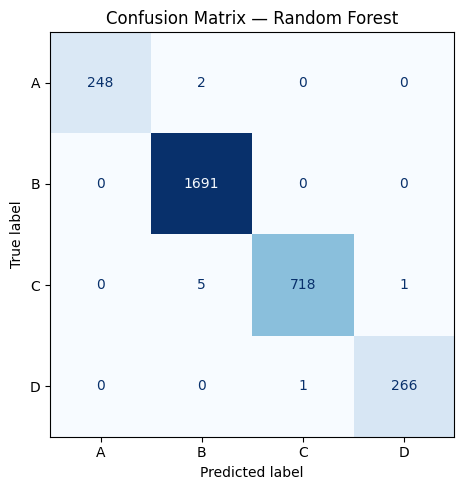

In [41]:
# Predictions
best_pred_enc = best_pipe.predict(X_val)
best_pred = label_encoder.inverse_transform(best_pred_enc)

print(f"Best model: {best_model_name}")

# Classification report
report_df = pd.DataFrame(
    classification_report(
        y_val,
        best_pred,
        labels=CLASS_ORDER,
        output_dict=True
    )
).T

display(report_df.style.format("{:.3f}"))

# Confusion Matrix
cm = confusion_matrix(y_val, best_pred, labels=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_model_name}", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Ordinal error analysis

In this task, not all mistakes have the same meaning.

A one-step error such as:

- **A → B**
- **B → C**
- **C → D**

is much less serious than a large jump such as:

- **A → D**
- **A → C**
- **B → D**

So the next diagnostic measures the **distance** between the true class and the predicted class.

| Distance | Interpretation |
|---:|---|
| **0** | exact prediction |
| **1** | adjacent class (usually acceptable / understandable) |
| **2** | large error |
| **3** | extreme error |

This is the most natural way to judge whether the model behaves well on an ordered financial-health scale.

,distance,count
0,0,2923
1,1,9


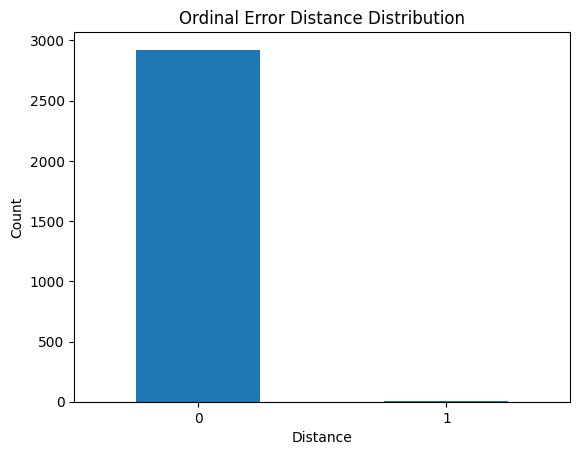

Severe errors (distance ≥ 2): 0


In [42]:
# Encode true and predicted labels
true_enc = label_encoder.transform(y_val)
pred_enc = label_encoder.transform(best_pred)

# Compute ordinal distance
error_distance = np.abs(true_enc - pred_enc)

# Build dataframe
error_df = pd.DataFrame({
    "true": y_val.values,
    "pred": best_pred,
    "distance": error_distance
})

# Distribution
error_dist = error_df["distance"].value_counts().sort_index()

error_dist_df = pd.DataFrame({
    "distance": error_dist.index,
    "count": error_dist.values
})

display(error_dist_df)

# Plot
error_dist.plot(kind="bar")
plt.title("Ordinal Error Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Severe errors
severe_errors = error_df[error_df["distance"] >= 2]

print(f"Severe errors (distance ≥ 2): {len(severe_errors)}")

if len(severe_errors) > 0:
    display(severe_errors.head(20))

### Reading the error distances

This is one of the most important validation checks.

A well-behaved model should show:

- a large concentration at **distance = 0**
- most remaining mistakes at **distance = 1**
- very few observations at **distance ≥ 2**

That pattern means the model is not only accurate — it is also **ordinally coherent**.

In practice, that is exactly what we want in a financial classification problem: when the model is wrong, it should usually be **close**, not wildly off.

## 9. Feature importance and interpretation

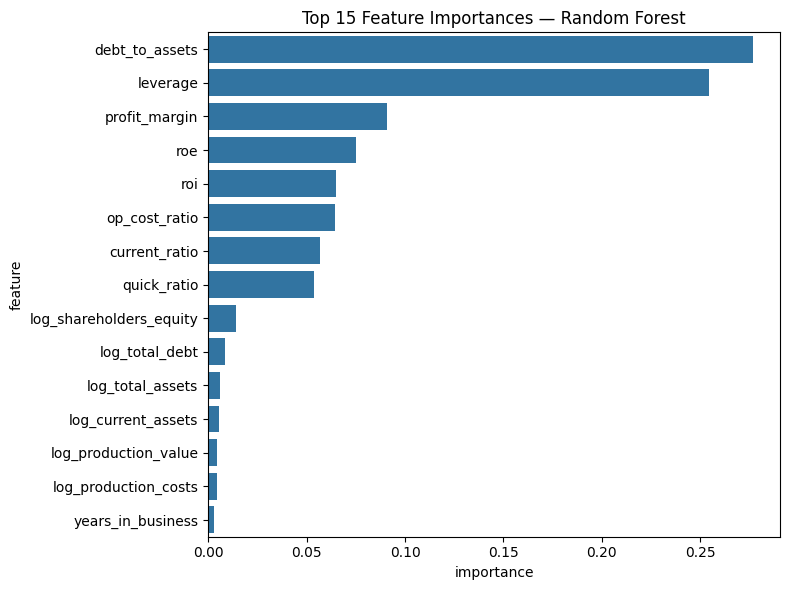

,feature,importance
4,debt_to_assets,0.276620
3,leverage,0.254434
2,profit_margin,0.091078
0,roe,0.074840
1,roi,0.065044
7,op_cost_ratio,0.064350
5,current_ratio,0.056925
6,quick_ratio,0.053751
11,log_shareholders_equity,0.014098
9,log_total_debt,0.008710


In [43]:
def get_feature_names_from_preprocessor(preprocessor, numeric_features, categorical_features):
    cat_names = []
    if categorical_features:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = ohe.get_feature_names_out(categorical_features).tolist()
    return numeric_features + cat_names

fitted_preprocessor = best_pipe.named_steps["preprocessor"]
feature_names = get_feature_names_from_preprocessor(
    fitted_preprocessor, numeric_features, categorical_features
)

model_obj = best_pipe.named_steps["model"]

if hasattr(model_obj, "feature_importances_"):
    importances = model_obj.feature_importances_
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(data=imp_df, x="importance", y="feature", ax=ax)
    ax.set_title(f"Top 15 Feature Importances — {best_model_name}", fontsize=12)
    plt.tight_layout()
    plt.show()

    display(imp_df)

elif hasattr(model_obj, "coef_"):
    coef = np.mean(np.abs(model_obj.coef_), axis=0)
    imp_df = pd.DataFrame({
        "feature": feature_names,
        "importance": coef
    }).sort_values("importance", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(data=imp_df, x="importance", y="feature", ax=ax)
    ax.set_title(f"Top 15 Feature Importances — {best_model_name}", fontsize=12)
    plt.tight_layout()
    plt.show()

    display(imp_df)

else:
    print("This model has no simple native feature importance.")

### What the model is really using

The feature-importance ranking is fully consistent with the EDA.

#### Primary drivers
- **profitability** (`roe`, `roi`, `profit_margin`)
- **leverage / debt pressure** (`leverage`, `debt_to_assets`, debt-related scale variables)
- **liquidity** (`current_ratio`, `quick_ratio`)
- **cost pressure** (`op_cost_ratio`)

#### Secondary but useful signals
- firm size proxies from the **log-transformed variables**
- selected **categorical context**
- **missingness indicators**, when the absence of information is itself informative

This is exactly the kind of ranking we want to see.

The model is relying on financially meaningful signals, not on obscure artifacts or unstable shortcuts.

### Final ranking summary

Before moving to the final fit, the tuned models are placed side by side in a compact ranking table.

This makes the decision transparent:

- the main ranking comes from **Weighted F1**
- but **Macro F1**, **Accuracy**, and **Ordinal MAE** remain visible
- so the final choice can be justified as a balance between raw performance and quality of errors

This is the cleanest way to show that the selected model is genuinely the strongest candidate overall.

In [44]:
final_table = comparison_df.copy()

# Ranking (primary metric: weighted F1)
final_table["rank"] = final_table["weighted_f1"].rank(
    ascending=False,
    method="dense"
)

# Sort
final_table = final_table.sort_values("rank").reset_index(drop=True)

# Round for readability
final_table_display = final_table.copy()
final_table_display[["weighted_f1", "macro_f1", "accuracy", "ordinal_mae"]] = \
    final_table_display[["weighted_f1", "macro_f1", "accuracy", "ordinal_mae"]].round(4)

display(final_table_display)

,weighted_f1,macro_f1,accuracy,ordinal_mae,model,rank
0,0.9969,0.9963,0.9969,0.0031,Random Forest (tuned),1.0
1,0.9949,0.9930,0.9949,0.0051,HistGradientBoosting (tuned),2.0


### Final decision

At this stage the choice is clear.

The selected model is the one that combines:

- the strongest overall **Weighted F1**
- good balance across classes
- low **ordinal error**
- and convincing behaviour under the two robustness checks

So the final choice is supported both statistically and structurally.

## 11. Test prediction and submission file

The retrained pipeline is applied to the test set exactly as-is:

- same engineered features,
- same preprocessing logic,
- same final classifier.

The predicted classes are then attached to the submission structure and exported in the required format.

This is the final out-of-sample step of the project.

In [45]:
X_full = df_model[FEATURES].copy()
y_full = df_model[TARGET].copy()
y_full_enc = label_encoder.transform(y_full)

final_pipe = best_pipe
final_pipe.fit(X_full, y_full_enc)

print("Final model re-trained on full dataset.")

Final model re-trained on full dataset.


In [46]:
X_test = df_test_model[FEATURES].copy()

test_pred_enc = final_pipe.predict(X_test)
test_pred = label_encoder.inverse_transform(test_pred_enc)

submission = test_df.copy()

cols_to_keep = [c for c in ["company_id", "fiscal_year"] if c in submission.columns]
submission = submission[cols_to_keep].copy()
submission["financial_health_class"] = test_pred

display(submission.head())

output_path = "../data/final/challenge2_submission.csv"
submission.to_csv(output_path, index=False)
print(f"Submission saved at: {output_path}")

,company_id,fiscal_year,financial_health_class
0,COMP_00000,2022,B
1,COMP_00000,2023,A
2,COMP_00001,2022,B
3,COMP_00001,2023,B
4,COMP_00002,2022,B


Submission saved at: ../data/final/challenge2_submission.csv


## 12. Final takeaway

The final pipeline stays fully aligned with the logic established in the EDA.

### Why the solution is strong

- **Feature engineering is selective**, not excessive  
  It adds only transformations that improve signal quality or preserve useful structure.

- **Validation is realistic**  
  The 2018–2020 / 2021 split respects the time direction of the challenge.

- **Model comparison is fair**  
  All candidates are tested under the same preprocessing and the same metrics.

- **Tuning is focused**  
  Only the strongest ensemble models are refined.

- **The final model is stress-tested**  
  Target shuffling and group-based validation confirm that the model is not exploiting leakage or memorization, but is instead capturing genuine economic signal.

- **Errors are well behaved**  
  Most mistakes stay close on the `A → D` scale, which is exactly what we want in an ordered rating problem.

### Final assessment

The selected model is not only accurate.  
It is also:

- **ordinally coherent**
- **economically interpretable**
- **robust under stricter validation**
- and **well aligned with the financial logic of the problem**

That makes it a strong and defensible final solution for the challenge.

In [47]:
# -----------------------------
# Temporal split
# -----------------------------
train_mask = df_model["fiscal_year"].isin([2018, 2019, 2020])
val_mask = df_model["fiscal_year"] == 2021

X_train = df_model.loc[train_mask, FEATURES].copy()
y_train = df_model.loc[train_mask, TARGET].copy()

X_val = df_model.loc[val_mask, FEATURES].copy()
y_val = df_model.loc[val_mask, TARGET].copy()

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (8896, 22)
Validation shape: (2932, 22)
